In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn import metrics
import seaborn as sn

In [2]:
import kagglehub

path = kagglehub.dataset_download("mathchi/diabetes-data-set")
csv_path = path + "/diabetes.csv"
data=pd.read_csv(csv_path)
data.head()

Using Colab cache for faster access to the 'diabetes-data-set' dataset.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [5]:
feature_cols = ['Pregnancies', 'Insulin', 'BMI','Age' , 'Glucose' , 'DiabetesPedigreeFunction']
x=data[feature_cols]
y=data['Outcome']

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3, random_state=5)
display(x_train.shape, y_train.shape, x_test.shape,y_test.shape)

(537, 6)

(537,)

(231, 6)

(231,)

In [9]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [12]:
model= SVC(kernel='rbf',random_state=0)
model.fit(x_train, y_train)
svc_prediction=model.predict(x_test)
print('svc_prediction:',svc_prediction)

svc_prediction: [0 0 0 0 0 0 1 1 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0
 0 0 0 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 0 1 0 1 1 1 0 0 0 0 1 1 0 1 0 0 1
 1 0 0 1 1 0 1 1 1 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 1 1 0 1 0 0 1 0 0
 1 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 1 0 1 0 0 0 0
 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 1 1 1 0 1 1 0 1 0 1 0 0 0 0 0 0 0 1 1 0 0 1 0 1 0 0 0 1 1 0 0 1 0 1 1 0
 0 1 0 0 1 0 0 0 1]


In [13]:
conf_mat=metrics.confusion_matrix(y_test, svc_prediction)
print('SVC [ kernerl - rbf ]')
print('Confusion Matrix : \n', conf_mat)
Accuracy_score=metrics.accuracy_score(y_test, svc_prediction)
print('Accuracy Score : ', Accuracy_score)
print('Accuracy in Percentage : ', int(Accuracy_score*100),'%')
print(classification_report(svc_prediction,y_test))

SVC [ kernerl - rbf ]
Confusion Matrix : 
 [[136  24]
 [ 22  49]]
Accuracy Score :  0.8008658008658008
Accuracy in Percentage :  80 %
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       158
           1       0.69      0.67      0.68        73

    accuracy                           0.80       231
   macro avg       0.77      0.77      0.77       231
weighted avg       0.80      0.80      0.80       231



In [16]:
model= SVC(kernel='linear', random_state=0)
model.fit(x_train, y_train)

SVC(kernel='linear', random_state=0)

[Text(0.5, 1.0, 'SVC [RBF]')]

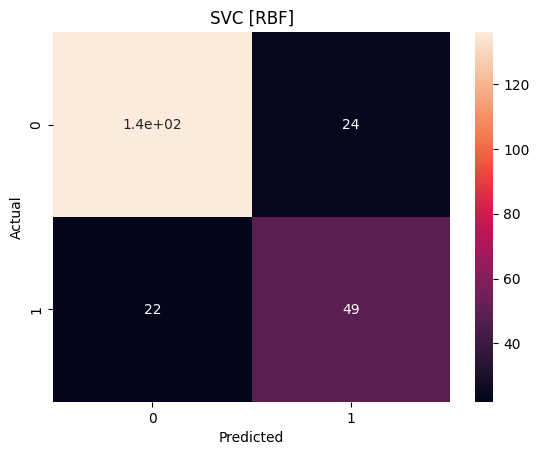

In [31]:
conf_mat=pd.crosstab(y_test, svc_prediction, rownames=[ 'Actual' ],colnames=['Predicted' ])
sn.heatmap(conf_mat, annot=True).set(title='SVC [RBF]')

In [28]:
conf_mat=metrics.confusion_matrix(y_test, svc_prediction)
print('SVC [ kernerl - linear ]' )
print('Confusion Matrix : \n', conf_mat)
Accuracy_score=metrics.accuracy_score(y_test, svc_prediction)
print('Accuracy Score : ', Accuracy_score)
print('Accuracy in Percentage : ', int(Accuracy_score*100),'%')
print(classification_report(svc_prediction,y_test))

SVC [ kernerl - linear ]
Confusion Matrix : 
 [[136  24]
 [ 22  49]]
Accuracy Score :  0.8008658008658008
Accuracy in Percentage :  80 %
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       158
           1       0.69      0.67      0.68        73

    accuracy                           0.80       231
   macro avg       0.77      0.77      0.77       231
weighted avg       0.80      0.80      0.80       231



[Text(0.5, 1.0, 'SVC [linear]')]

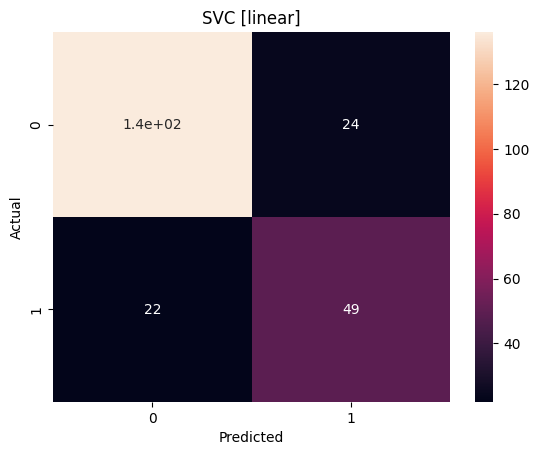

In [29]:
conf_mat=pd.crosstab(y_test, svc_prediction, rownames=['Actual' ],colnames=['Predicted' ])
sn.heatmap(conf_mat, annot=True).set(title='SVC [linear]')